In [28]:
import pandas as pd
import numpy as np

bmi = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/3d644765-ad61-4322-87bb-b62ff9fbf324.csv")
trainer = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/a0471d9d-fc86-41ff-8324-51722c1fe3e0.csv")
workout = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/e243e01a-9d5e-437a-a38a-792ed0c50193.csv")
diet = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/de797ef3-dfae-4f75-be3a-2f8365ce9539.csv")
peak = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/af15bde7-77e7-4a36-9e4d-c6ab799b91d3.csv")
trend = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/a5347aad-0961-4927-8810-7095058fc9ed.csv")
top = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/1b0e1f56-2804-44b9-8f82-525e7bd2245f.csv")
protein = pd.read_csv("s3://gym-analytics-bucket/query-results/query-output/2026/04/16/36753f68-732a-44c4-a16d-8543d56cb396.csv")

In [18]:
bmi.columns

Index(['member_id', 'name', 'age', 'gender', 'weight_kg', 'height_cm', 'bmi',
       'bmi_category', 'membership_type', 'trainer_name', 'specialization'],
      dtype='object')

In [19]:
peak.columns

Index(['workout_month', 'workout_plan', 'session_count'], dtype='object')

In [21]:
trend.columns

Index(['member_id', 'week', 'avg_weekly_calories', 'avg_protein_g',
       'avg_carbs_g', 'avg_fat_g'],
      dtype='object')

In [20]:
diet.columns

Index(['member_id', 'name', 'avg_daily_calorie_intake',
       'avg_calories_burned_per_session', 'avg_protein_g', 'meal_type'],
      dtype='object')

In [22]:
top.columns

Index(['member_id', 'name', 'membership_type', 'trainer_name',
       'avg_calories_burned', 'avg_protein_g', 'total_workout_sessions'],
      dtype='object')

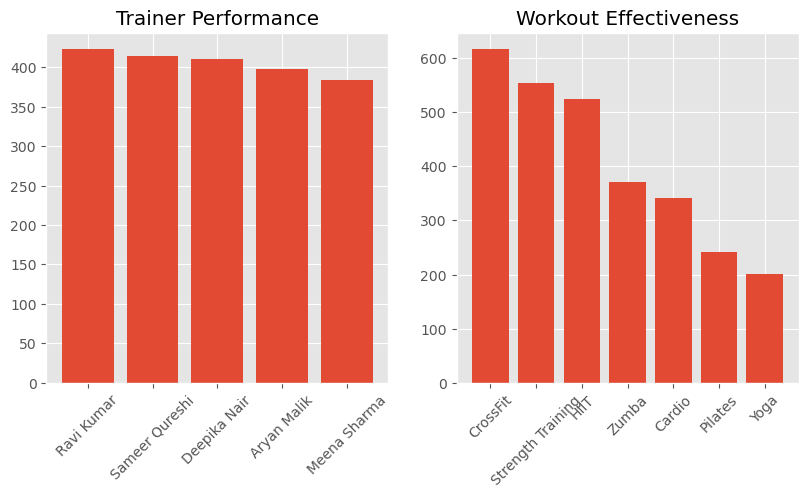

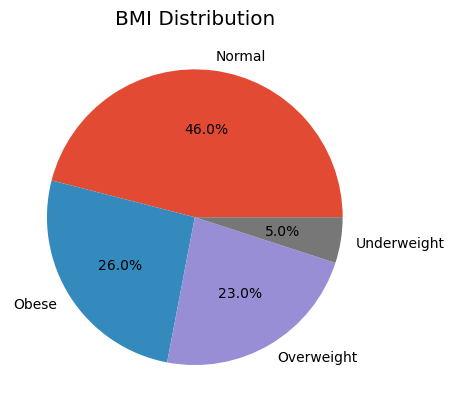

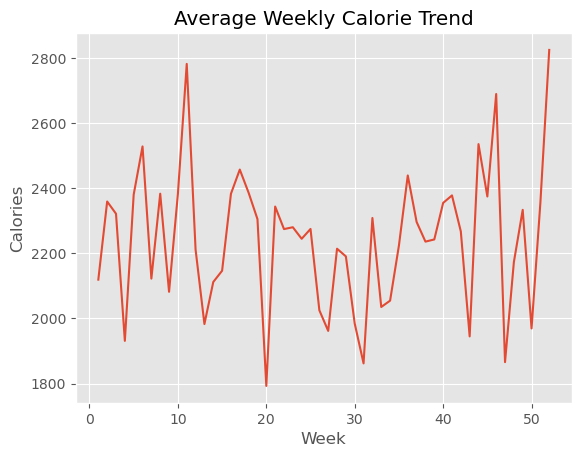

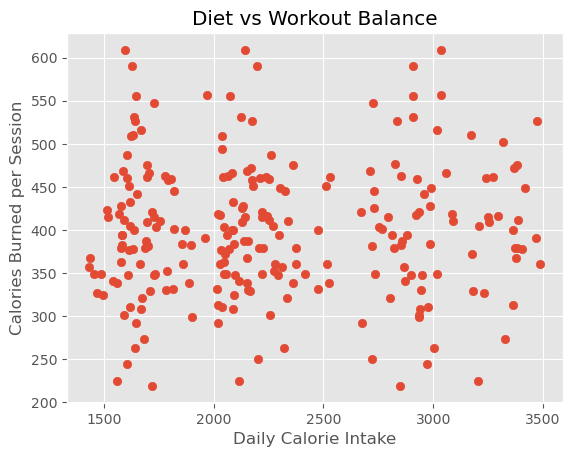

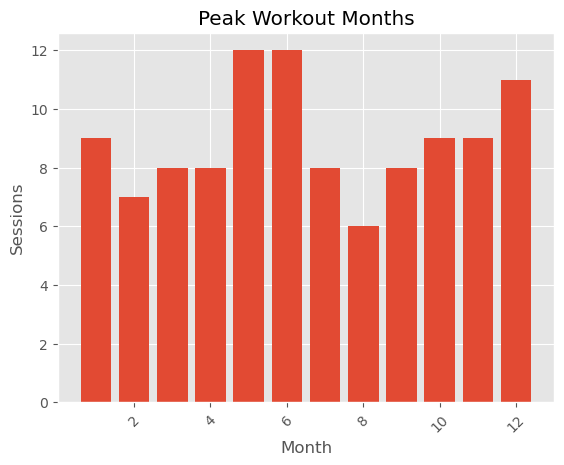

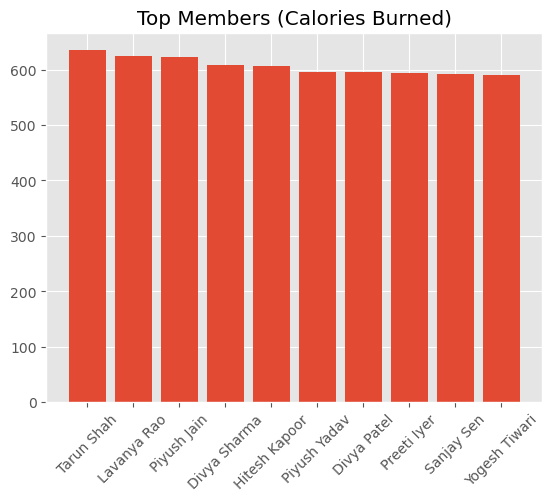

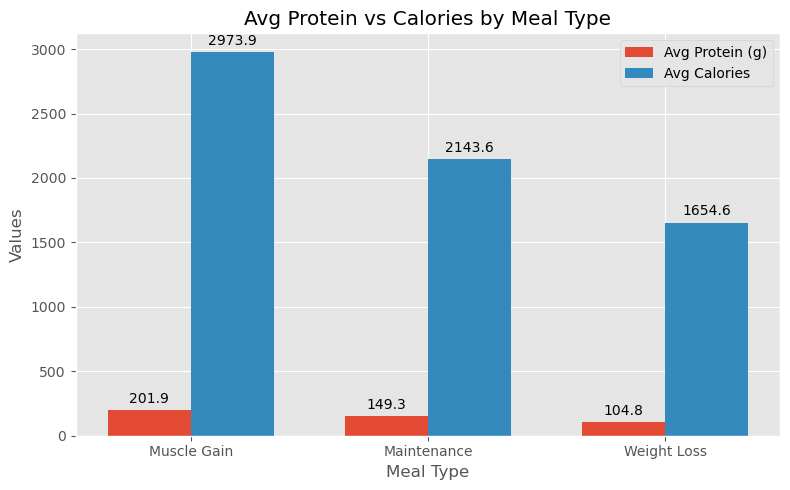

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# 1 Trainer Performance
plt.subplot(2,3,1)
plt.bar(trainer['trainer_name'], trainer['avg_calories_per_session'])
plt.xticks(rotation=45)
plt.title("Trainer Performance")

# 2 Workout Effectiveness
plt.subplot(2,3,2)
plt.bar(workout['workout_plan'], workout['avg_calories_burned'])
plt.xticks(rotation=45)
plt.title("Workout Effectiveness")

# 3 BMI Distribution
bmi_counts = bmi['bmi_category'].value_counts()

plt.figure()
plt.pie(bmi_counts.values, labels=bmi_counts.index, autopct='%1.1f%%')
plt.title("BMI Distribution")
plt.show()

# 4 Diet Trend
weekly_avg = trend.groupby('week')['avg_weekly_calories'].mean()

plt.figure()
plt.plot(weekly_avg.index, weekly_avg.values)
plt.title("Average Weekly Calorie Trend")
plt.xlabel("Week")
plt.ylabel("Calories")
plt.show()

#calorie burned
plt.figure()
plt.scatter(diet['avg_daily_calorie_intake'], diet['avg_calories_burned_per_session'])
plt.title("Diet vs Workout Balance")
plt.xlabel("Daily Calorie Intake")
plt.ylabel("Calories Burned per Session")
plt.show()

# 5 Peak Months
plt.figure()
plt.bar(peak['workout_month'], peak['session_count'])
plt.xticks(rotation=45)
plt.title("Peak Workout Months")
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.show()

# 6 Top Members
top_sorted = top.sort_values(by='avg_calories_burned', ascending=False).head(10)

plt.figure()
plt.bar(top_sorted['name'], top_sorted['avg_calories_burned'])
plt.xticks(rotation=45)
plt.title("Top Members (Calories Burned)")
plt.show()

#avg protein vs avg calories
x = np.arange(len(protein['meal_type']))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, protein['avg_protein'], width, label='Avg Protein (g)')
bars2 = ax.bar(x + width/2, protein['avg_calories'], width, label='Avg Calories')

# Labels & title
ax.set_xlabel("Meal Type")
ax.set_ylabel("Values")
ax.set_title("Avg Protein vs Calories by Meal Type")
ax.set_xticks(x)
ax.set_xticklabels(protein['meal_type'])
ax.legend()

# 🔥 Add values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',   # 1 decimal
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),   # slight offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()